<a href="https://colab.research.google.com/github/dhafi7/midterm-Machine-Learning/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.preprocessing import StandardScaler

drive.mount('/content/drive')

# 2. Load Dataset dari Path Drive
file_path = '/content/drive/MyDrive/Datasets ML 3/clusteringmidterm.csv'
df_cluster = pd.read_csv(file_path)

# 3. Preprocessing Dasar
df_prep = df_cluster.drop('CUST_ID', axis=1)

df_prep['MINIMUM_PAYMENTS'] = df_prep['MINIMUM_PAYMENTS'].fillna(df_prep['MINIMUM_PAYMENTS'].median())
df_prep['CREDIT_LIMIT'] = df_prep['CREDIT_LIMIT'].fillna(df_prep['CREDIT_LIMIT'].median())

# 4. Feature Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

print(f"Data berhasil dimuat dari: {file_path}")
print(f"Ukuran dataset setelah scaling: {df_scaled.shape}")
display(df_cluster.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data berhasil dimuat dari: /content/drive/MyDrive/Datasets ML 3/clusteringmidterm.csv
Ukuran dataset setelah scaling: (8950, 17)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


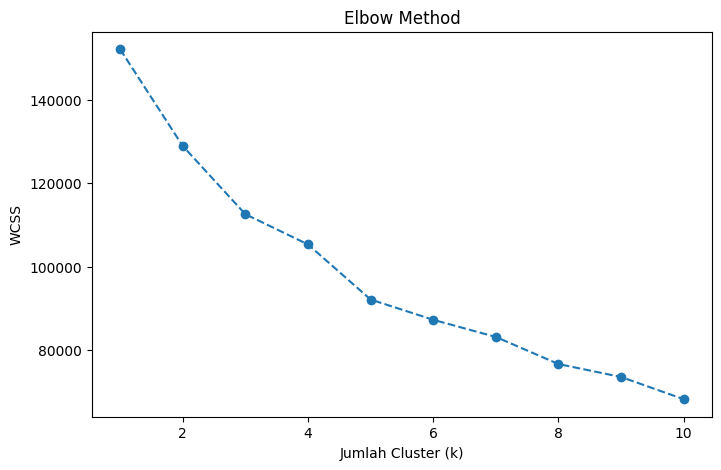

In [ ]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:

k = 4
kmeans_final = KMeans(n_clusters=k, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(df_scaled)

df_cluster['Cluster'] = clusters

score = silhouette_score(df_scaled, clusters)
print(f"Silhouette Score untuk {k} Cluster: {score:.4f}")

Silhouette Score untuk 4 Cluster: 0.1665


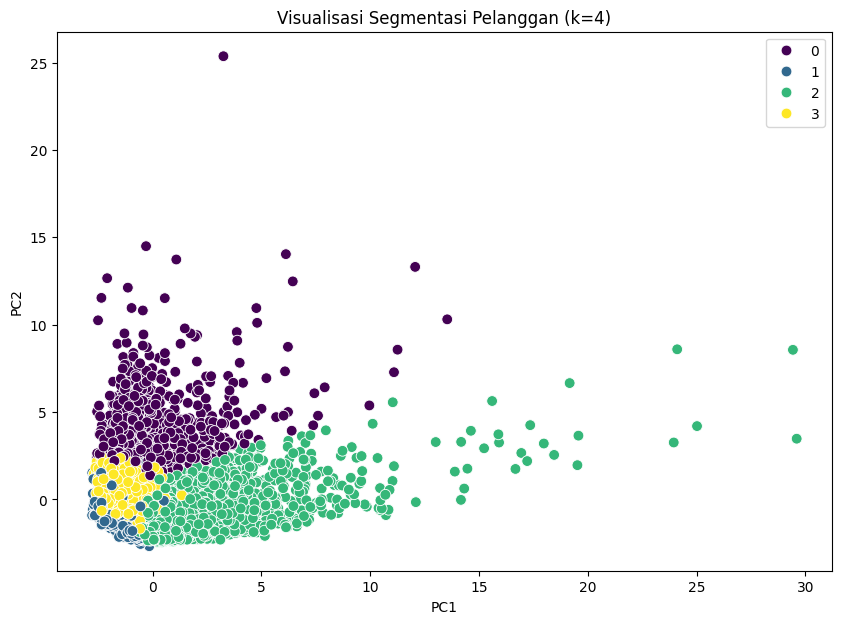

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

# Plotting
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=60)
plt.title(f'Visualisasi Segmentasi Pelanggan (k={k})')
plt.legend()
plt.show()

In [ ]:

cluster_profile = df_cluster.groupby('Cluster').mean(numeric_only=True)

fitur_kunci = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']
tabel_profil = cluster_profile[fitur_kunci].copy()

# 3. Kategori
nama_kategori = {
    0: "Cluster 0 (Pelanggan Pasif / Hemat)",
    1: "Cluster 1 (Pembelanja Aktif / Transactors)",
    2: "Cluster 2 (Pengguna VIP / Limit Tinggi)",
    3: "Cluster 3 (Peminjam Tunai / Cash Advance Users)"
}

tabel_profil.index = tabel_profil.index.map(nama_kategori)

print("--- PROFILING SEGMENTASI PELANGGAN ---")
display(tabel_profil.T)

--- PROFILING SEGMENTASI PELANGGAN ---


Cluster,Cluster 0 (Pelanggan Pasif / Hemat),Cluster 1 (Pembelanja Aktif / Transactors),Cluster 2 (Pengguna VIP / Limit Tinggi),Cluster 3 (Peminjam Tunai / Cash Advance Users)
BALANCE,5010.394668,108.430006,1253.817942,1495.324927
PURCHASES,716.017789,350.247868,2182.022178,283.482824
CASH_ADVANCE,5065.974690,299.482324,234.564524,782.285268
CREDIT_LIMIT,8208.653578,3632.537386,5121.987288,3216.349960
PURCHASES_FREQUENCY,0.327150,0.320591,0.928413,0.207097
CASH_ADVANCE_FREQUENCY,0.508502,0.035072,0.041717,0.157514
